## Sprint 3: Machine Learning e Artificial Intelligence

     Equipe Dataway 

Integrantes:
- Isabella Heder - RM561300
- João Victor D'Alessio - RM561050
- Milena Barbosa - RM558913
- Paulo Luchini - RM561477
- Angelo Rabello - RM561926


In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 300)  
pd.set_option('display.max_colwidth', None)  

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Carregamento dos Dados tratados:

Foi feito um pipeline de tratamento dos dados, os dados finais (tratados) ficaram assim:

| Nome do Campo | Descrição | Tipo de Dado | Formato | Restrições | Obrigatório | Lista de Valores |
|---------------|------------|--------------|----------|------------|--------------|------------------|
| Número | Identificador único e sequencial do incidente. | Texto | INCXXXXXXX (onde XXXXXXX é um número sequencial) | N/A | Sim | N/A |
| Prioridade | Nível de urgência e impacto do incidente. | Texto | X - aaaaaaa (onde X é um número e aaaaaaa é um texto) | Somente as prioridades 1, 2 e 3 entram para o KPI | Sim | 1 - Crítica; 2 - Alta; 3 - Média; 4 - Baixa; 5 - Muito Baixa |
| Produto | Produto ou serviço afetado pelo incidente. | Texto | N/A | N/A | Sim | N/A |
| Categoria | Classificação primária do tipo de incidente. | Texto | N/A | N/A | Sim | N/A |
| Subcategoria | Classificação secundária que refina a Categoria. | Texto | Associada à Categoria | Necessita Categoria para seleção | Sim | N/A |
| Grupo designado | Equipe responsável pela solução do incidente. | Texto | TeamXX (Team14, Team12, Team06 etc.) | N/A | Sim | N/A |
| Item de configuração | Ativo de TI específico que apresenta o problema. | Texto | N/A | Caso não exista, preencher com "SEM_IC" | Não | N/A |
| Aberto | Data e hora de registro do incidente. | Data/Hora | dd/mm/aaaa hh:mm:ss | N/A | Sim | N/A |
| Resolvido | Data e hora em que a equipe técnica resolveu o incidente. | Data/Hora | dd/mm/aaaa hh:mm:ss | Caso ausente, utilizar horário de Encerrado | Não | N/A |
| Encerrado | Data e hora da finalização formal do incidente. | Data/Hora | dd/mm/aaaa hh:mm:ss | N/A | Sim | N/A |
| Duração | Tempo total entre abertura e resolução/encerramento. | Numérico | Segundos | N/A | Sim | N/A |
| Código de fechamento | Motivo formal para encerramento do incidente. | Texto | N/A | Caso ausente, derivar pelo Status | Não | N/A |
| Descrição resumida | Título conciso do incidente. | Texto | N/A | N/A | Sim | N/A |
| Solução | Tipo de solução aplicada ao incidente. | Texto | N/A | Se resolvido e sem informação: "NÃO_DOCUMENTADA"; se "Sem Intervenção": "SEM_SOLUCAO" | Não | Contorno; Definitiva; NÃO_DOCUMENTADA; SEM_SOLUCAO |
| Aberto por | Origem da abertura do incidente. | Texto | N/A | N/A | Sim | Manual; Monitoramento |
| Incidente Pai | Referência a incidente relacionado ou duplicado. | Texto | INCXXXXXXX (onde XXXXXXX é um número sequencial) | Pode ser nulo | Não | N/A |
| Status | Estado atual do incidente no ciclo de vida. | Texto | N/A | N/A | Sim | Aguardando Problema; Encerrado; Encerrado Automaticamente; Sem Intervenção |
| Entrou para KPI? | Indica se o incidente participa do cálculo dos KPIs. | Booleano | SIM / NAO | N/A | Sim | SIM; NAO |
| KPI Violado? | Indica se houve violação do SLA. | Texto | SIM / NAO / NAO_APLICAVEL | Se Entrou para KPI? = NAO, então KPI Violado? = NAO_APLICAVEL | Sim | SIM; NAO; NAO_APLICAVEL |
| tem_resolucao | Flag indicando se o campo Resolvido possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_pai | Flag indicando se o campo Incidente Pai possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_produto | Flag indicando se o campo Produto possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_categoria | Flag indicando se o campo Categoria possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_subcategoria | Flag indicando se o campo Subcategoria possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_item_config | Flag indicando se o campo Item de Configuração possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_CF | Flag indicando se o campo Código de Fechamento possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| kpi_violado | Flag indicando se KPI Violado? = SIM. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| kpi_nao_aplicavel | Flag indicando se KPI Violado? = NAO_APLICAVEL. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |


In [2]:
df = pd.read_excel('LW-DATASET-TRATADO.xlsx')
df.shape

(122543, 28)

#### Verificando a "saúde" do dataset:
``Incidente Pai`` é a única coluna que restou sem valores nulos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               122543 non-null  object        
 3   Categoria             122543 non-null  object        
 4   Subcategoria          122543 non-null  object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  122543 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             122543 non-null  datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  122543 non-null  object        
 12  Descrição resumida    122543 non-null  object        
 13 

Dataset sem valores nulos:

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,Aberto,Resolvido,Encerrado,Duração,tem_resolucao,tem_pai,tem_produto,tem_categoria,tem_subcategoria,tem_item_config,tem_CF,kpi_violado,kpi_nao_aplicavel
count,122543,122543,122543,1.225430e+05,122543.000000,122543.000000,122543.000000,122543.000000,122543.000000,122543.000000,122543.000000,122543.000000,122543.000000
mean,2025-09-18 22:10:35.012746752,2025-09-21 19:24:00.098071808,2025-09-22 18:42:48.700783104,2.485470e+05,0.328383,0.123442,0.364019,0.365765,0.365774,0.985474,0.304497,0.002024,0.791094
min,2023-01-02 20:19:58,2024-12-27 00:50:52,2025-01-01 00:10:45,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-09-02 10:30:35,2025-09-03 10:52:51,2025-09-03 18:35:03.500000,2.630000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,2025-10-14 00:11:49,2025-10-15 14:34:14,2025-10-15 23:55:36,9.780000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,2025-11-26 18:11:42.500000,2025-11-27 14:17:31.500000,2025-11-28 01:53:03,4.240500e+03,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,2025-12-31 23:45:18,2025-12-31 23:45:32,2025-12-31 23:45:32,8.828048e+07,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,NaN,NaN,2.480123e+06,0.469627,0.328946,0.481156,0.481646,0.481648,0.119644,0.460196,0.044941,0.406529


### Distribuição das Variáveis

##### Categóricas:

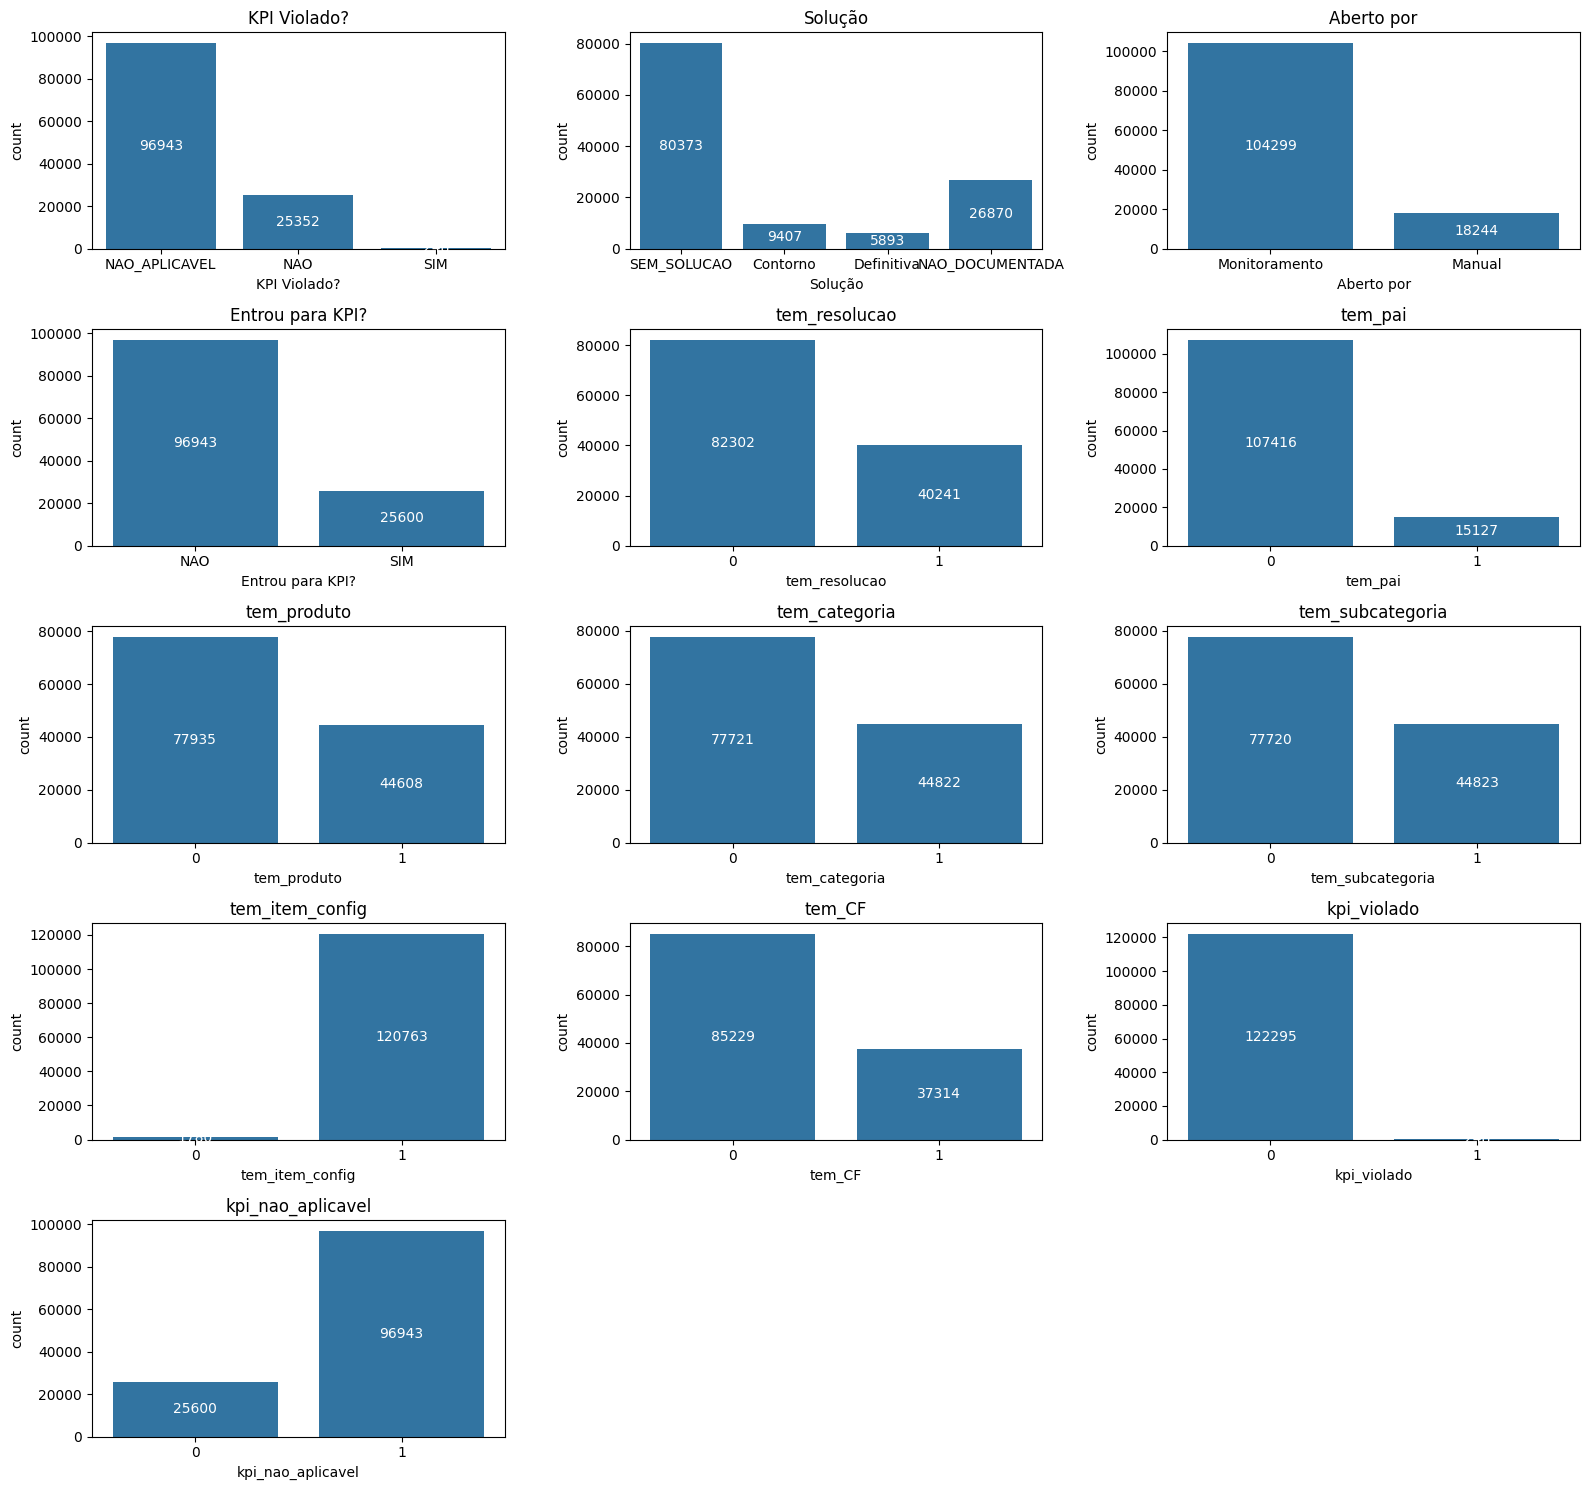

In [6]:
variaveis = [ 'KPI Violado?', 'Solução', 'Aberto por', 'Entrou para KPI?', 
             'tem_resolucao', 'tem_pai', 'tem_produto', 'tem_categoria', 
             'tem_subcategoria', 'tem_item_config', 'tem_CF', 'kpi_violado', 'kpi_nao_aplicavel']

plt.figure(figsize=(16, 15))
for i, col in enumerate(variaveis, 1):
    ax = plt.subplot(5, 3, i)
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fmt='%d', color='white')

plt.tight_layout()
plt.show()

##### **Interpretação:** ^^
- A maioria dos incidentes não entra para o KPI
- Entre os incidentes que entram no KPI, a taxa de violação de SLA é extremamente baixa
- A abertura dos incidentes acontece mais por monitoramento
- Poucos incidentes possuem relacionamento hierárquico (Incidente Pai)
- A maioria dos incidentes não tiveram solução ou não tiveram solução documentada
    - A menor parte das soluções foram definitivas
- A maior parte da coluna de produtos, categoria e subcategorias não tem valor identificado
    - mesma coisa para codigo de fechamento

A maioria dos incidentes tem ``prioridade`` baixa ou média

In [7]:
df['Prioridade'].value_counts()

Prioridade
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64

A maior parte dos ``produtos`` é MONITORING_AUTO --> não é um produto

Portanto a maior parte de ``produtos`` é o lhco

In [8]:
df['Produto'].value_counts().head(10)

Produto
MONITORING_AUTO    77823
lhco               12835
lsin                7342
lcem                5878
lhvp                4454
lrev                3784
lcho                1368
lcsi                1085
lsaa                 919
lrel                 905
Name: count, dtype: int64

Maior parte dos ``status`` não tem intervenção

In [9]:
df['Status'].value_counts()

Status
Sem Intervenção              80373
Encerrado Automaticamente    26830
Encerrado                    15339
Aguardando Problema              1
Name: count, dtype: int64

Team14 é o ``grupo`` que cuida da maior parte dos incidentes

In [10]:
df['Grupo designado'].value_counts().head(10)

Grupo designado
Team14    92775
Team11     9790
Team05     9276
Team09     3425
Team12     2173
Team03     1306
Team10     1172
Team17      743
Team02      579
Team01      306
Name: count, dtype: int64

Em geral ``Item de configuração`` é balanceado, mas com predominância de IC00014    

In [11]:
df['Item de configuração'].value_counts().head(10)

Item de configuração
IC00014    6069
IC00019    4435
IC00008    4196
IC00349    3271
IC00002    3119
SEM_IC     1780
IC00325    1600
IC00004    1149
IC00604    1079
IC00725     988
Name: count, dtype: int64

A maior parte de ``categorias`` e ``subcategorias`` são de INFRA_Monitoramento --> não é categoria

In [12]:
df['Categoria'].value_counts().head(10)

Categoria
INFRA_Monitoramento    77717
cat71                   7335
cat77                   4425
cat85                   4319
cat76                   4304
cat73                   3388
cat31                   2483
cat137                  1716
cat91                   1246
cat36                   1086
Name: count, dtype: int64

In [13]:
df['Subcategoria'].value_counts().head(10)

Subcategoria
INFRA_Monitoramento_Geral    77717
sub7                          4668
sub336                        4297
sub36                         2741
sub387                        2494
sub427                        2192
sub225                        1638
sub392                        1625
sub127                        1470
sub438                        1116
Name: count, dtype: int64

A maior parte da coluna de ``Código de fechamento`` é composta por AUTO_SEM_INTERVENCAO 

In [14]:
df['Código de fechamento'].value_counts().head(10)

Código de fechamento
AUTO_SEM_INTERVENCAO            80373
Falha de Aplicação              20612
Falha de Sistema Operacional     5009
AUTO_ENCERRADO                   2434
NAO_DOCUMENTADO                  2422
Falha causada pelo cliente       1796
Sem retorno do solicitante       1527
Falha não reproduzida            1401
Incidente causado por Change     1353
Falha de Cloud                   1202
Name: count, dtype: int64

##### **Contínua:**

Duração (em segundos)

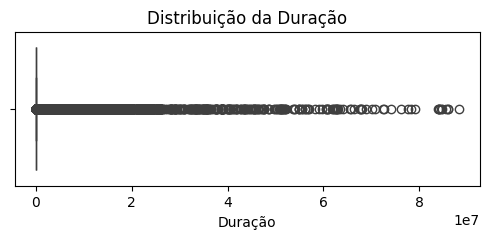

In [15]:
plt.figure(figsize=(6, 2))
sns.boxplot(x='Duração', data=df)
plt.title('Distribuição da Duração')
plt.show()

Tornando de melhor compreensão:

In [16]:
df['Duração'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

count    1.225430e+05
mean     2.485470e+05
std      2.480123e+06
min      1.000000e+00
25%      2.630000e+02
50%      9.780000e+02
75%      4.240500e+03
90%      1.843480e+04
95%      1.010522e+05
99%      6.157757e+06
max      8.828048e+07
Name: Duração, dtype: float64

| Medida        |   Segundos | Aproximadamente       |
| ------------- | ---------: | --------------------- |
| Min           |          1 | 1 segundo             |
| 25%           |        263 | 4,4 min               |
| 50% (mediana) |        978 | 16,3 min              |
| 75%           |      4.240 | 1,18 h                |
| 90%           |     18.435 | 5,1 h                 |
| 95%           |    101.052 | 28,1 h                |
| 99%           |  6.157.757 | 71,3 dias             |
| Máx           | 88.280.480 | 1.022 dias (2,8 anos) |


In [17]:
df['duracao_log'] = np.log1p(df['Duração'])

_________________

### **Sazonalidade**

##### Evolução da Quantidade de Incidentes por Dia

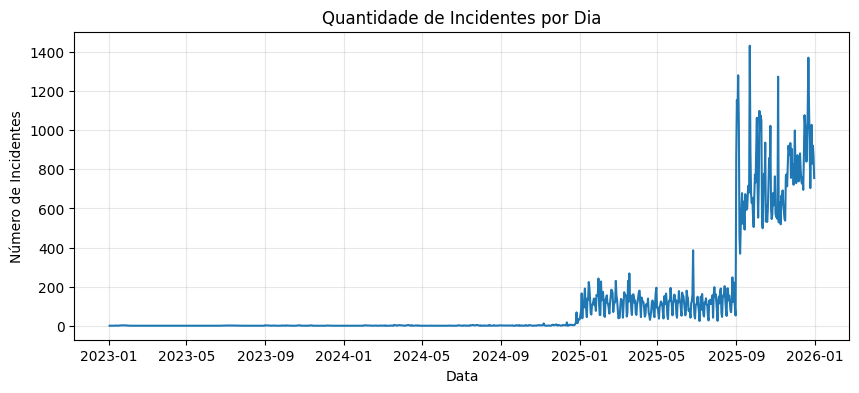

In [18]:
incidentes_dia = (
    df.groupby(df['Aberto'].dt.date)
      .size()
)

plt.figure(figsize=(10,4))
incidentes_dia.plot()
plt.title('Quantidade de Incidentes por Dia')
plt.xlabel('Data')
plt.ylabel('Número de Incidentes')
plt.grid(True, alpha=0.3)
plt.show()

Principais insights ^^
- A partir do final de 2024/início de 2025 ocorre uma mudança brusca na quantidade de incidentes registrados (aumenta muito)
- Em setembro de 2025 há um novo salto expressivo no volume
- Após setembro de 2025, os incidentes passam a oscilar entre aproximadamente 500 e mais de 1.000 registros por dia.

##### Heatmap de Incidentes por Mês e Ano

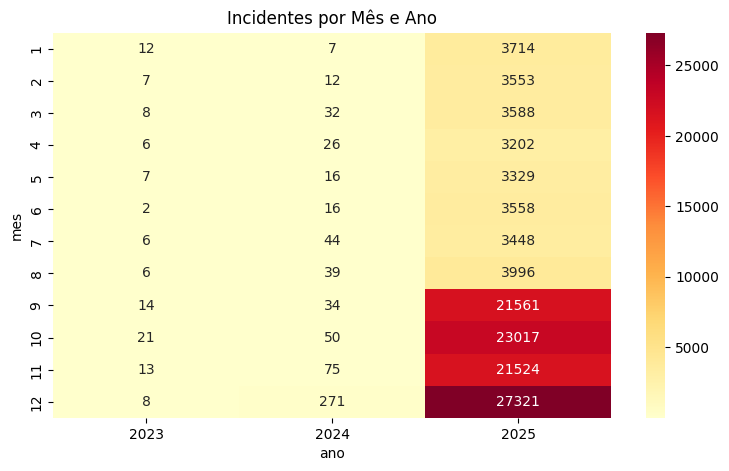

In [19]:
tmp = df.copy()
tmp['ano'] = tmp['Aberto'].dt.year
tmp['mes'] = tmp['Aberto'].dt.month

pivot_mes = pd.pivot_table(
    tmp,
    index='mes',
    columns='ano',
    values='Número',
    aggfunc='count'
)

plt.figure(figsize=(9,5))
sns.heatmap(pivot_mes, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Incidentes por Mês e Ano')
plt.show()

Principais insights ^^
- 2023 apresenta volume muito reduzido de incidentes
- 2024 mostra crescimento gradual, especialmente no segundo semestre
- O volume cresce fortemente em 2025
- Setembro, Outubro, Novembro e Dezembro de 2025 concentram os maiores volumes registrados.

##### Quantidade de Incidentes por Dia da Semana

C:\Users\IsabellaHeder\AppData\Local\Temp\ipykernel_30756\2432216178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dias_semana[i] for i in range(7)], y=incidentes_semana.values, palette='Blues_r')


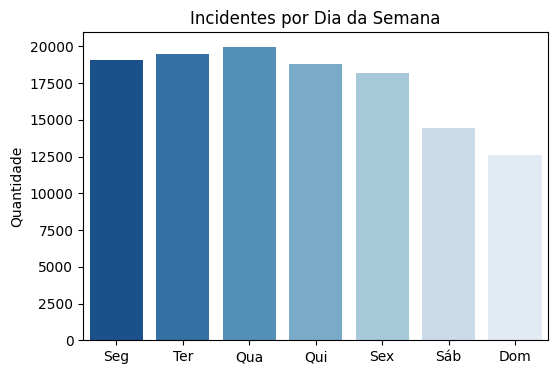

In [20]:
dias_semana = {0:'Seg', 1:'Ter', 2:'Qua', 3:'Qui', 4:'Sex', 5:'Sáb', 6:'Dom'}
tmp['dia_semana'] = tmp['Aberto'].dt.dayofweek
incidentes_semana = (tmp.groupby('dia_semana').size().reindex(range(7)))

plt.figure(figsize=(6,4))
sns.barplot(x=[dias_semana[i] for i in range(7)], y=incidentes_semana.values, palette='Blues_r')

plt.title('Incidentes por Dia da Semana')
plt.ylabel('Quantidade')
plt.show()

Principais insights ^^
- Quarta-feira apresenta a maior quantidade de incidentes da semana.
- Segunda, terça e quinta-feira possuem volumes semelhantes e elevados.
- Há queda significativa nos finais de semana.
- Domingo é o dia com menor volume de incidentes.

--

Vendo dias da semana conforme meses

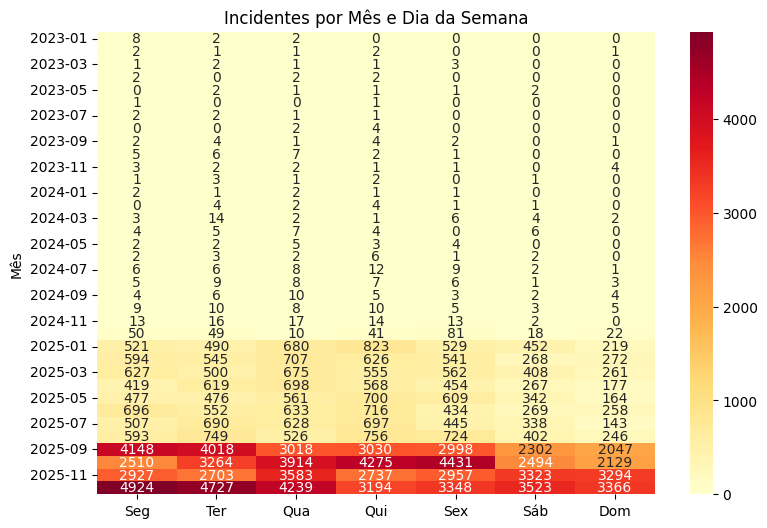

In [ ]:
tmp['ano_mes'] = tmp['Aberto'].dt.to_period('M').astype(str)
heatmap_mes = pd.crosstab(tmp['ano_mes'], tmp['dia_semana'])
heatmap_mes = heatmap_mes.rename(columns={0:'Seg',1:'Ter',2:'Qua',3:'Qui',4:'Sex',5:'Sáb',6:'Dom'})

plt.figure(figsize=(9,6))
sns.heatmap(heatmap_mes, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Incidentes por Mês e Dia da Semana')
plt.xlabel('')
plt.ylabel('Mês')
plt.show()


##### Quantidade de Incidentes por Hora do Dia

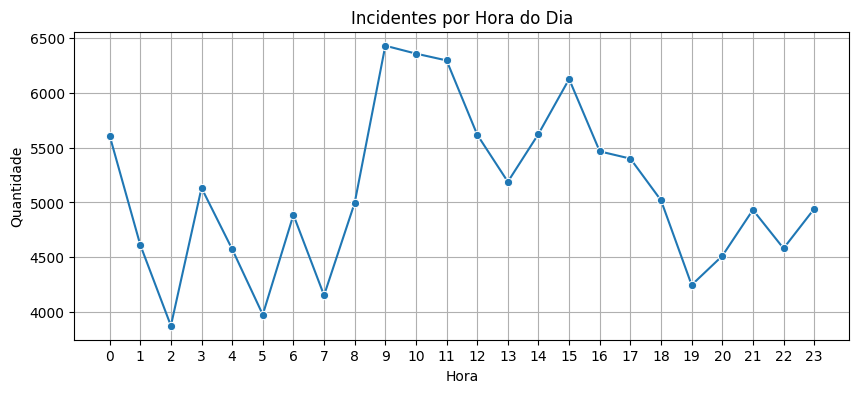

In [21]:
tmp['hora'] = tmp['Aberto'].dt.hour
incidentes_hora = (tmp.groupby('hora').size().reindex(range(24), fill_value=0))

plt.figure(figsize=(10,4))
sns.lineplot(x=incidentes_hora.index, y=incidentes_hora.values,marker='o')

plt.title('Incidentes por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Quantidade')
plt.xticks(range(24))
plt.grid(True)
plt.show()

Principais insights ^^
- O volume de incidentes é menor durante a madrugada (entre 2h e 5h)
- A partir das 8h ocorre um crescimento significativo
- O pico máximo acontece entre 9h e 11h
- segundo pico relevante por volta das 15h
- Após as 18h observa-se redução

##### Heatmap de Incidentes por Dia da Semana e Hora

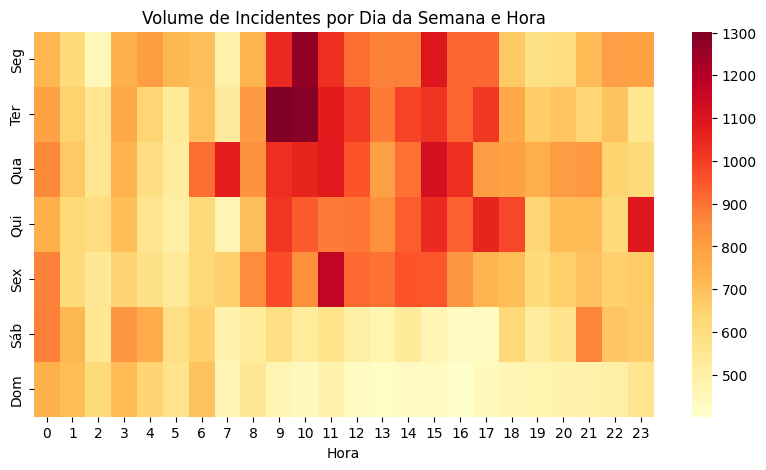

In [22]:
heatmap_data = pd.pivot_table(tmp, index='dia_semana', columns='hora', values='Número', aggfunc='count', fill_value=0)
heatmap_data.index = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

plt.figure(figsize=(10,5))
sns.heatmap(heatmap_data, cmap='YlOrRd')
plt.title('Volume de Incidentes por Dia da Semana e Hora')
plt.xlabel('Hora')
plt.ylabel('')
plt.show()

Principais insights ^^
- maiores volumes concentram-se entre terça e quinta-feira
- entre 9h e 17h apresenta a maior incidência
- Quarta-feira mantém volume elevado durante quase todo o horário comercial
- Quinta-feira tem incidentes 23h
- Sábado e domingo apresentam volume significativamente menor em todas as horas.

``Verificando o aumento de incidentes as 9h e 10h nas terças-feiras``

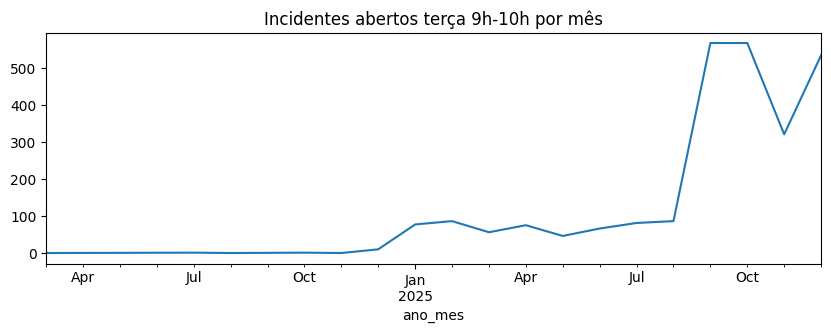

In [27]:
tmp['ano_mes'] = tmp['Aberto'].dt.to_period('M')
pico_terca = tmp[(tmp['dia_semana'] == 1) & (tmp['hora'].isin([9,10]))]

pico_terca.groupby('ano_mes')['Número'].count().plot(figsize=(10,3))
plt.title('Incidentes abertos terça 9h-10h por mês')
plt.show()

In [ ]:
pico = tmp[(tmp['dia_semana']==1) & (tmp['hora'].isin([9,10]))]

print(pico['Aberto por'].value_counts())
print("\n")

print(pico['Produto'].value_counts().head(5))
print("\n")

print(pico['Categoria'].value_counts().head(5))
print("\n")

print(pico['Grupo designado'].value_counts().head(5))
print("\n")

print(pico['Prioridade'].value_counts())
print("\n")

print(pico['Descrição resumida'].value_counts().head(10))

Aberto por
Monitoramento    1977
Manual            611
Name: count, dtype: int64


Produto
MONITORING_AUTO    1544
lhco                280
lsin                155
lhvp                131
lcem                 99
Name: count, dtype: int64


Categoria
INFRA_Monitoramento    1544
cat31                   131
cat71                   106
cat85                   101
cat73                    94
Name: count, dtype: int64


Grupo designado
Team14    1914
Team11     329
Team05     166
Team09      83
Team12      27
Name: count, dtype: int64


Prioridade
3 - Média          1006
4 - Baixa           807
2 - Alta            770
5 - Muito Baixa       5
Name: count, dtype: int64


Descrição resumida
Problem: Check Application Monitoring                    397
Problem: Unavailable by ICMP ping                        358
Problem: Check Local Administrators                      219
Problem: Processor load is too high P3                    78
Problem: Apache Busy Workers                              65
Probl

O pico observado nas terças-feiras entre 09h e 10h não está associado ao comportamento normal dos usuários. A análise mostra que aproximadamente 76% dos incidentes desse período são gerados automaticamente por sistemas de monitoramento


Porém, no gráfico seguinte (esse embaixo), vemos que não existe esse "efeito terça". Em 2025 os percentuais ficam relativamente equilibrados, com diferenças pequenas (O salto de setembro/2025 afetou a semana inteira)

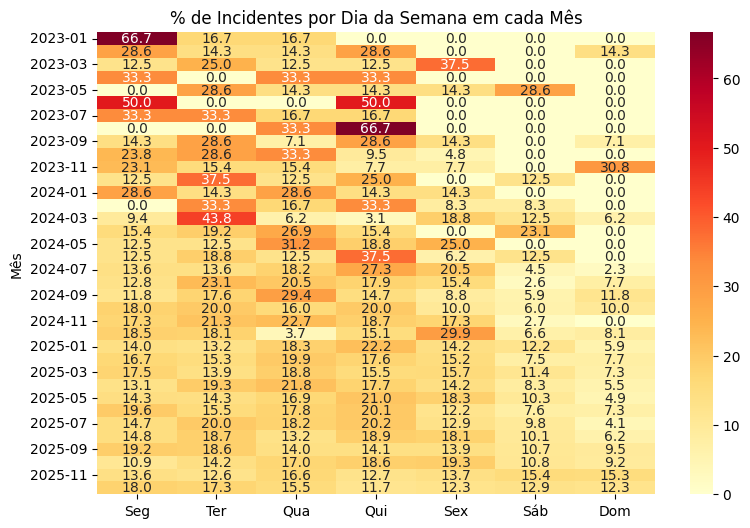

In [54]:
heatmap_pct = pd.crosstab(tmp['ano_mes'], tmp['dia_semana'], normalize='index') * 100
heatmap_pct.columns = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

plt.figure(figsize=(9,6))
sns.heatmap(heatmap_pct, cmap='YlOrRd', annot=True, fmt='.1f')
plt.title('% de Incidentes por Dia da Semana em cada Mês')
plt.xlabel('')
plt.ylabel('Mês')
plt.show()

____________
### Correlação entre Variáveis

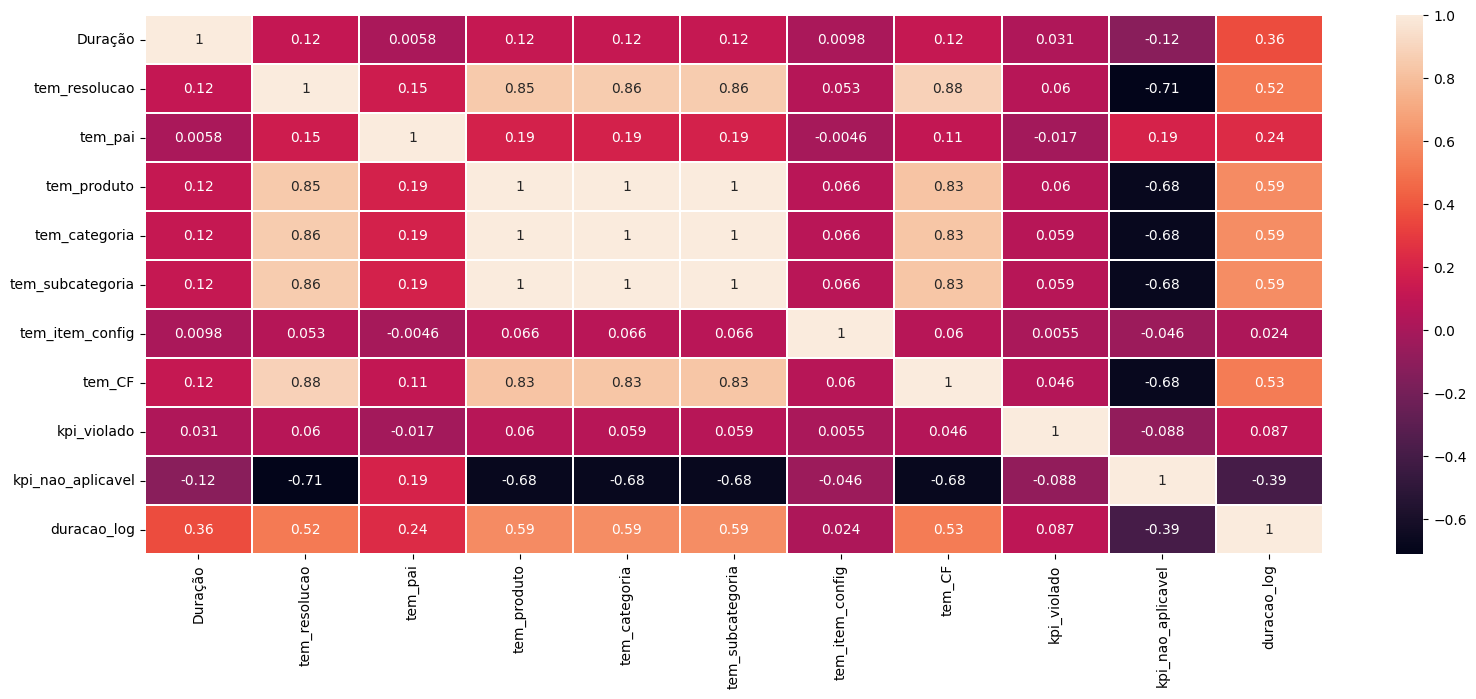

In [23]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(19, 7))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2)
plt.show()

- tem_produto, tem_categoria e tem_subcategoria possuem correlação praticamente perfeita (≈ 1,00) -- redundantes
- tem_CF apresenta forte correlação com tem_resolucao (0,88) 
    - inc. resolvidos tendem a possuir código de fechamento registrado
- tem_resolucao também possui forte correlação com Produto, Categoria e Subcategoria 
    - informações completas tendem a possuir resolução documentada
- kpi_nao_aplicavel apresenta forte correlação negativa com tem_resolucao 
    - inc. fora do KPI tendem a ter menos informações de resolução registradas.
- duracao_log possui correlação moderada com Produto, Categoria e Subcategoria 
    - cadastro mais completo tendem a estar associados a maiores tempos de duração

_______________
### Feature Engineering 1

Eu testei uma variedade de features diferentes, e essas foram as que trouxeram o melhor desempenho do modelo

``Feature temporal``

In [24]:
df['mes'] = df['Aberto'].dt.month

``Feature de texto (a partir da Descrição resumida)``

In [25]:
df['Descrição resumida'].value_counts().head()

Descrição resumida
Problem: Check Application Monitoring                    28728
Problem: Free disk space is less than 10% on volume /     4770
Problem: Check Application Monitoring VIP                 4281
Problem: Unavailable by ICMP ping                         4133
Problem: Apache Busy Workers                              3925
Name: count, dtype: int64

In [26]:
df['tem_AM'] = df['Descrição resumida'].str.contains('Application Monitoring', case=False, na=False).astype(int)

_____________
### Correlação entre novas variáveis

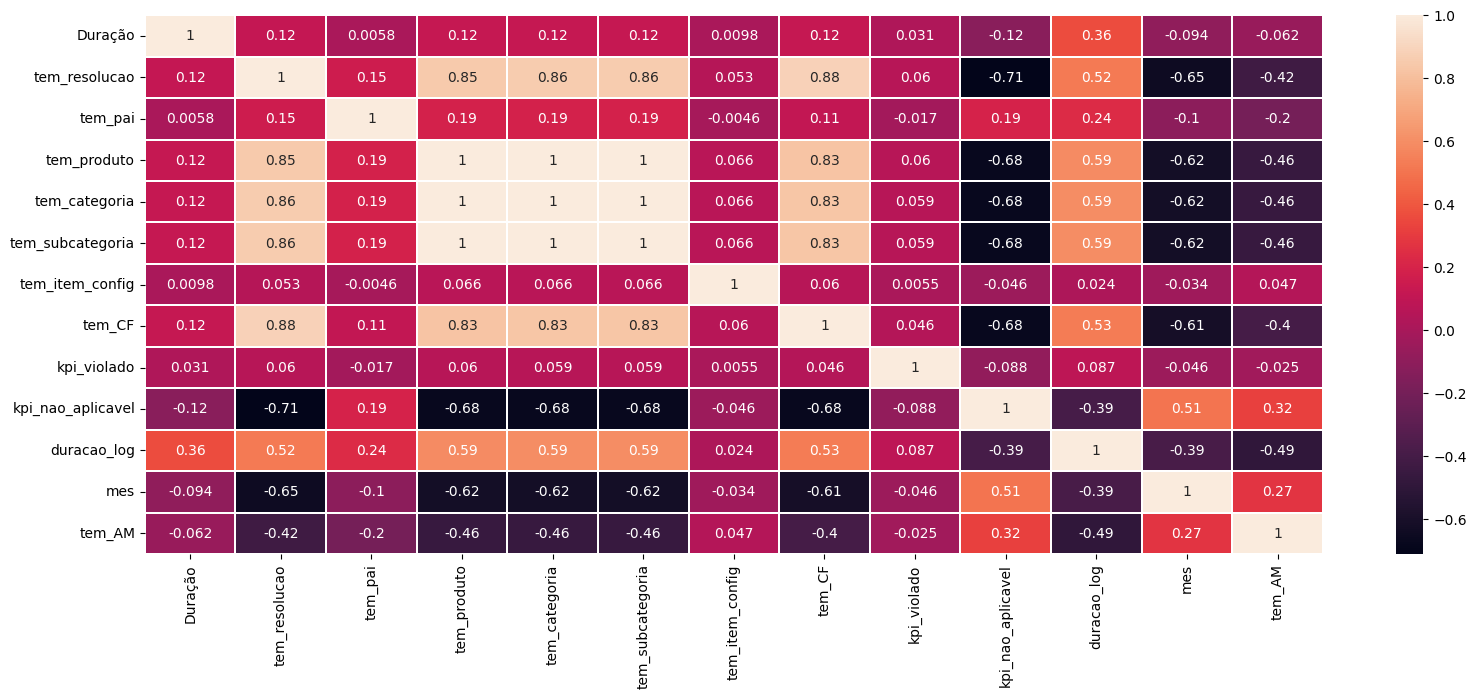

In [27]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(19, 7))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2)
plt.show()

## **Modelo Preditivo para Quantidade de Incidentes**

Para prever volume de incidentes futuros (D+1 e D+7), a unidade de análise não deve mais ser o incidente individual, mas sim o dia.

Para o forecast preciso transformar o dataset atual em:
| Data       | qtd\_incidentes |
| ---------- | --------------: |
| 2024-01-01 |             237 |
| 2024-01-02 |             198 |
| 2024-01-03 |             214 |

Passo 1: criar série diária

In [28]:
df_model = df[df['Aberto'] >= '2025-01-01'].copy()
serie = (df_model.groupby(df_model['Aberto'].dt.date).size().reset_index(name='qtd_incidentes'))
serie.columns = ['data', 'qtd_incidentes']
serie['data'] = pd.to_datetime(serie['data'])

Passo 2: Agregar informações úteis do dia

In [29]:
indicadores = (df.groupby(df['Aberto'].dt.date).agg({'tem_AM':'mean'}).reset_index().rename(columns={'Aberto': 'data'}))

In [30]:
serie['data'] = pd.to_datetime(serie['data'])
indicadores['data'] = pd.to_datetime(indicadores['data'])

Passo 3: Juntar tudo

In [31]:
serie = serie.merge(indicadores, on='data')

Passo 4: Criar features de séries temporais
- Lags

In [32]:
serie['lag_1'] = serie['qtd_incidentes'].shift(1)
serie['lag_7'] = serie['qtd_incidentes'].shift(7)

Médias móveis

In [33]:
serie['media_7d'] = serie['qtd_incidentes'].rolling(7).mean()

In [34]:
serie.head()

,data,qtd_incidentes,tem_AM,lag_1,lag_7,media_7d
0,2025-01-01,34,0.058824,NaN,NaN,NaN
1,2025-01-02,55,0.036364,34.0,NaN,NaN
2,2025-01-03,77,0.000000,55.0,NaN,NaN
3,2025-01-04,166,0.000000,77.0,NaN,NaN
4,2025-01-05,39,0.051282,166.0,NaN,NaN


Passo 5: Calendário

In [35]:
serie['mes'] = serie['data'].dt.month
serie['dia_semana'] = serie['data'].dt.dayofweek

Passo 6: Criar os alvos

In [36]:
serie['target_d1'] = serie['qtd_incidentes'].shift(-1)
serie['target_d7'] = serie['qtd_incidentes'].shift(-7)

Removendo linhas com NaN gerados pelos lags e targets:
- os NaNs são criados por conta de que não existe valor antes do primeiro do dataset (ou dos 7 primeiros etc)

In [37]:
serie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            365 non-null    datetime64[ns]
 1   qtd_incidentes  365 non-null    int64         
 2   tem_AM          365 non-null    float64       
 3   lag_1           364 non-null    float64       
 4   lag_7           358 non-null    float64       
 5   media_7d        359 non-null    float64       
 6   mes             365 non-null    int32         
 7   dia_semana      365 non-null    int32         
 8   target_d1       364 non-null    float64       
 9   target_d7       358 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int32(2), int64(1)
memory usage: 25.8 KB


#### Correlação das Variáveis com as Targets novas

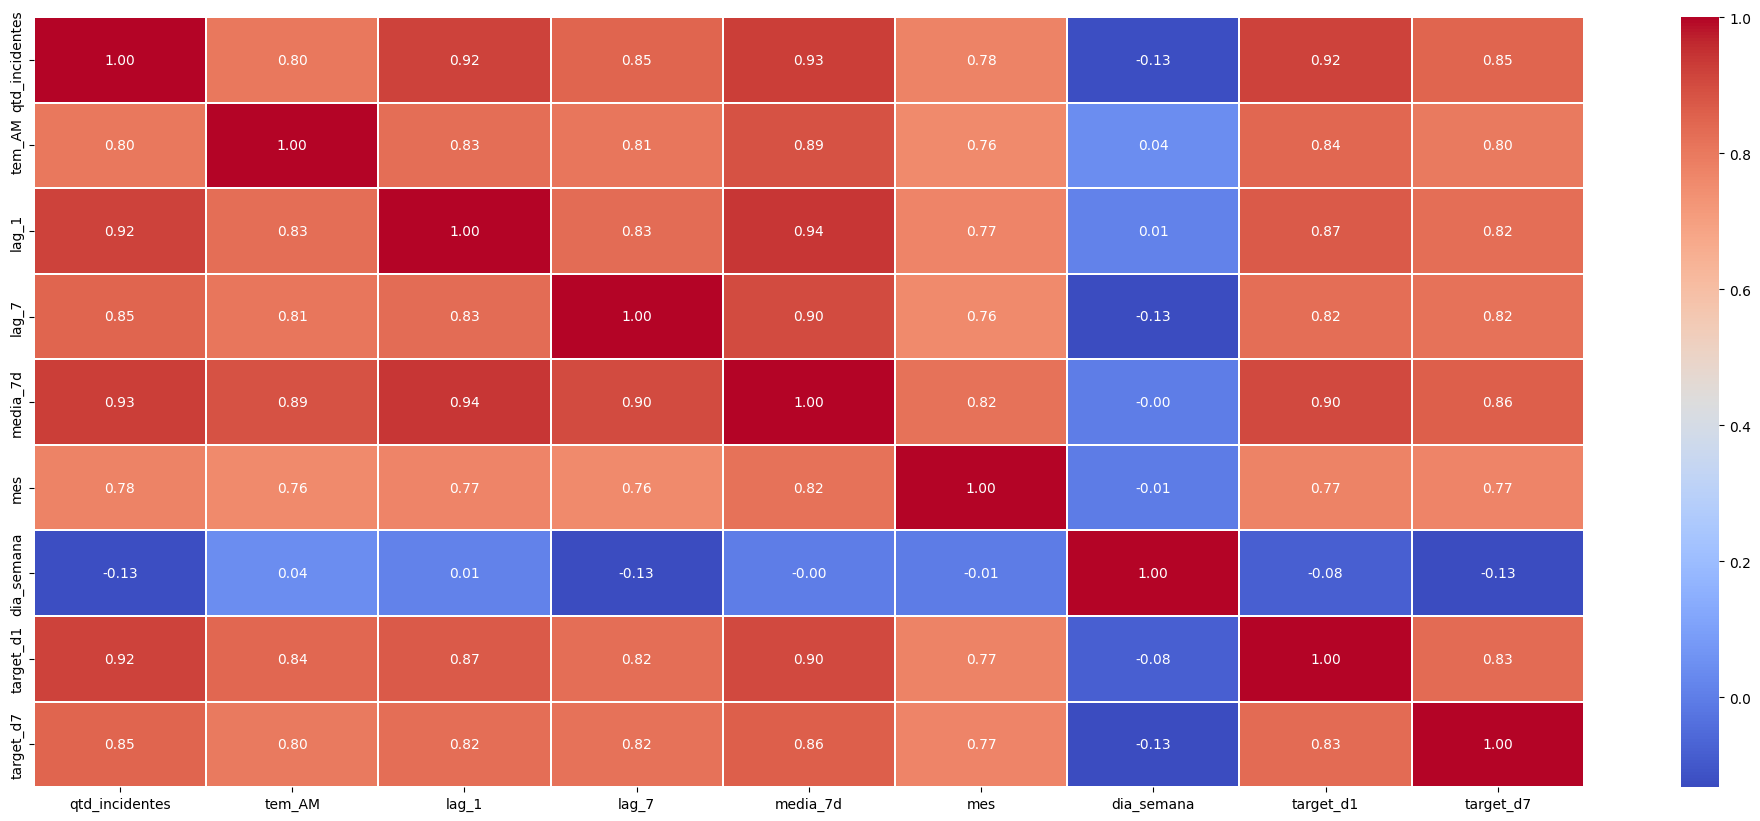

In [38]:
matriz_correlacao = serie.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(25, 10))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2, cmap='coolwarm', fmt='.2f')
plt.show()

Interpretação:

| Feature             | Corr com target\_d1 |
| ------------------- | ------------------- |
| lag\_1              | 0.86                |
| media\_7d           | 0.90                |
| tem\_AM             | 0.85                |
| lag\_7              | 0.82                |

##
| Feature             | Corr com target\_d7 |
| ------------------- | ------------------- |
| media\_7d           | 0.86                |
| lag\_1              | 0.82                |
| lag\_7              | 0.82                |
| tem\_AM             | 0.80                |

Essas foram outras features que eu criei, mas que **não utilizei no modelo** (apesar de terem correlação)
- modelo performou melhor sem elas

In [39]:
serie['lag_2'] = serie['qtd_incidentes'].shift(2)
serie['lag_14'] = serie['qtd_incidentes'].shift(14)
serie['lag_30'] = serie['qtd_incidentes'].shift(30)
serie['media_14d'] = serie['qtd_incidentes'].rolling(14).mean()
serie['media_30d'] = serie['qtd_incidentes'].rolling(30).mean()
serie['std_7d'] = serie['qtd_incidentes'].rolling(7).std()
serie['media_3d'] = serie['qtd_incidentes'].rolling(3).mean()
serie['trend_7_30'] = serie['media_7d'] - serie['media_30d']
serie['variacao_1d'] = serie['lag_1'] - serie['lag_2']
serie['variacao_7d'] = serie['lag_1'] - serie['lag_7']

Retirando os nulos que ficaram no dataset por conta dos lags e medias e etc

In [40]:
serie_model = serie.dropna().copy()
len(serie_model)

328

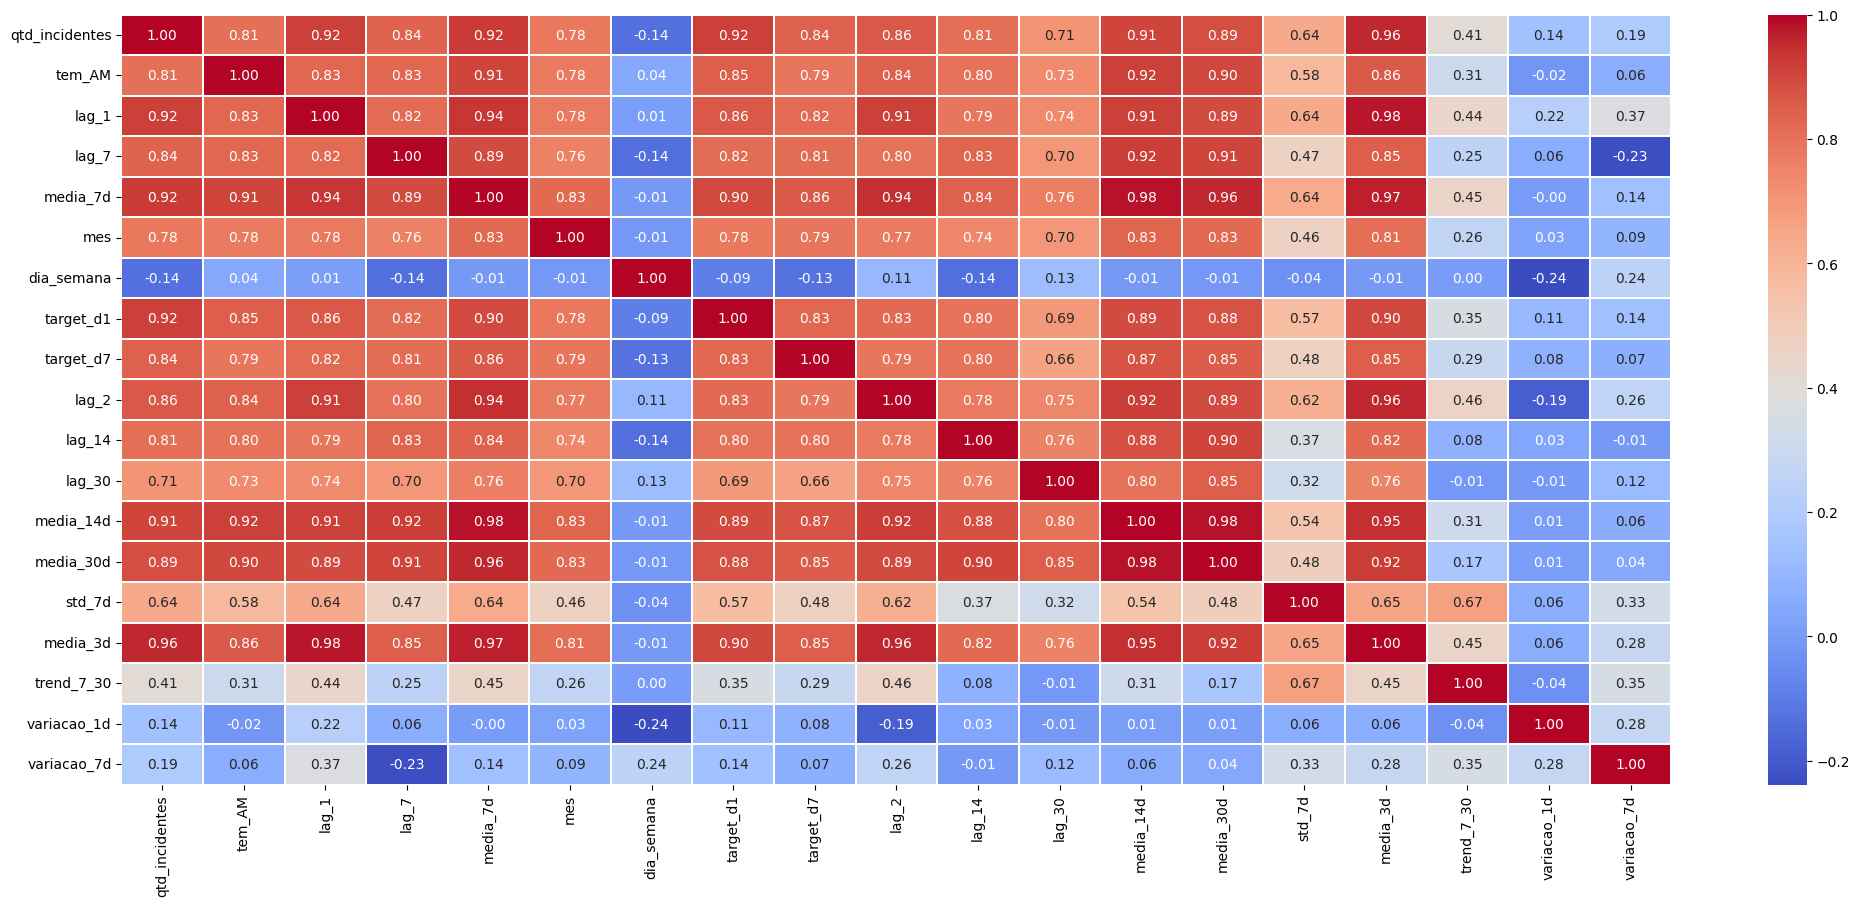

In [41]:
matriz_correlacao = serie_model.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(25, 10))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2, cmap='coolwarm', fmt='.2f')
plt.show()

Vou salvar o dataset para utilizar em sprints de outros professores

In [42]:
serie_model.to_csv('serie_temporal_incidentes.csv', index=False)

Features finais:

In [43]:
features = ['lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes']

Separação temporal

In [44]:
split = int(len(serie_model) * 0.8)

train = serie_model.iloc[:split]
test = serie_model.iloc[split:]

### **Modelo D+1**

In [46]:
X_train = train[features]
X_test = test[features]

y_train = train['target_d1']
y_test = test['target_d1']

In [47]:
from sklearn.ensemble import GradientBoostingRegressor
model_d1 = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.03, random_state=42)

model_d1.fit(X_train, y_train)
pred_d1 = model_d1.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print('MAE:', mean_absolute_error(y_test, pred_d1))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_d1)))
print('R²:', r2_score(y_test, pred_d1))

MAE: 106.19048479581187
RMSE: 142.31539629278473
R²: 0.37498421731306764


In [49]:
serie['qtd_incidentes'].mean()

np.float64(333.7287671232877)

Para uma média de 333 incidentes diários, meu modelo erra estourando 142 por dia

In [50]:
pd.DataFrame({'feature': features, 'importance': model_d1.feature_importances_}).sort_values('importance', ascending=False)

,feature,importance
4,mes,0.579613
2,media_7d,0.312287
1,lag_7,0.046537
0,lag_1,0.033086
3,tem_AM,0.028477


Salvando modelo para usar em outras sprints que pediram

In [ ]:
import pickle
with open('modelo_incidentes_d1.pkl', 'wb') as f:
    pickle.dump(model_d1, f)

In [52]:
#features = ['media_14d', 'lag_1', 'mes']
#X_train = train[features]
#X_test = test[features]

In [53]:
y_train = train['target_d7']
y_test = test['target_d7']

model_d7 = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    random_state=42
)

model_d7.fit(X_train, y_train)

pred_d7 = model_d7.predict(X_test)

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print('MAE:', mean_absolute_error(y_test, pred_d7))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_d7)))
print('R²:', r2_score(y_test, pred_d7))

MAE: 128.59880669498216
RMSE: 165.829596872635
R²: 0.129299133652662


In [55]:
pd.DataFrame({'feature': features, 'importance': model_d7.feature_importances_
}).sort_values('importance', ascending=False)

,feature,importance
0,lag_1,0.564091
4,mes,0.177610
2,media_7d,0.147576
1,lag_7,0.101139
3,tem_AM,0.009584


### Clusterização de Incidentes